# Tiingo through navi's client

`TiingoClient` is navi's async wrapper over Tiingo's end-of-day API, and it is
what the MCP server calls underneath. Two methods: `get_meta` for what a symbol
is and how far back it goes, `get_prices` for the bars.

Same arc as `walkthrough.ipynb` — discovery, fetch, plot — reached the other
way. The requests go to Tiingo rather than to `localhost`, so **the MCP server
does not need to be running**. The vendor credential does need to be
configured: `TIINGO_API_KEY` in `../navi/.env`, since here the key travels on
every request instead of sitting on the server.

In [1]:
%reload_ext autoreload
%autoreload 2

import sys
sys.path.append('../')

from datetime import date
sys.path.append("../../")   # repo root, for `clients`

from matplotlib import pyplot
from lib import config
from clients.models.tiingo import TiingoMeta, TiingoPrice

from utils import (
    client_raw_meta,
    client_meta,
    show_field_aliases,
    client_raw_prices,
    client_prices,
    plot_client_series,
)

pyplot.style.use(config.glyfish_style)

## 1. Discovery

Tiingo publishes no catalog — no search call, no list of symbols — so an
identifier cannot be discovered here, only confirmed. That makes `get_meta` the
discovery step: it resolves the symbol, names the instrument, and reports the
coverage window every later request has to sit inside. `MSFT` below; the
symbol has to come from outside the API either way.

Take the payload as it arrives first. `get_meta` parses before it returns, so
this reaches past it for the client's private `_get`.

In [2]:
_ = await client_raw_meta("MSFT")

{
  "description": "Microsoft (Nasdaq \"MSFT\" @microsoft) creates platforms and tools powered by AI to deliver innovative solutions that meet the evolving needs of our customers. The technology company is committed to making AI available broadly and doing so responsibly, with a mission to empower every person and every organization on the planet to achieve more. SOURCE Microsoft Corp.",
  "endDate": "2026-09-11",
  "exchangeCode": "NASDAQ",
  "name": "Microsoft Corporation",
  "startDate": "1986-03-13",
  "ticker": "MSFT"
}


Tiingo speaks camelCase: `exchangeCode`, `startDate`, `endDate`. `get_meta`
returns those same six fields as a `TiingoMeta`, and the differences are
exactly what the model added — the names arrive snake_case, and the two dates
stop being strings.

In [3]:
meta = await client_meta("MSFT")

MSFT -- Microsoft Corporation
  exchange_code: NASDAQ
  start_date:    1986-03-13  (date)
  end_date:      2026-09-11  (date)


The renaming is not string munging. Each model field declares its wire name as
a pydantic *alias*, so the mapping is a table that can be read off the class
rather than a convention to be trusted.

In [4]:
show_field_aliases(TiingoMeta)

TiingoMeta: attribute <- wire field
  ticker         <- ticker
  name           <- name
  exchange_code  <- exchangeCode  (aliased)
  start_date     <- startDate  (aliased)
  end_date       <- endDate  (aliased)
  description    <- description


## 2. Retrieving a series

`meta.start_date` is a `datetime.date`, so clamping a requested range to the
coverage window is a comparison rather than a parsing exercise. Ask for more
history than exists and the window hands back the earliest date that does.

In [5]:
requested_start = date(1980, 1, 1)
if meta.start_date != None and requested_start < meta.start_date:
    print(f"requested start date {requested_start} is before coverage start date {meta.start_date}")
    start_date = max(requested_start, meta.start_date)
    end_date = meta.end_date

    print(f"requested from {requested_start}, coverage opens {meta.start_date}")
    print(f"fetching       {start_date} -> {end_date}")

requested start date 1980-01-01 is before coverage start date 1986-03-13
requested from 1980-01-01, coverage opens 1986-03-13
fetching       1986-03-13 -> 2026-09-11


Before the whole window, four bars around 18 February 2003 — the day
Microsoft's most recent stock split took effect. Raw first, one bar of it.

In [6]:
_ = await client_raw_prices("MSFT", "2003-02-14", "2003-02-20")

4 raw rows
{
  "adjClose": 14.6897625747,
  "adjHigh": 14.750589749,
  "adjLow": 14.2244346919,
  "adjOpen": 14.3704199101,
  "adjVolume": 90446400,
  "close": 48.3,
  "date": "2003-02-14T00:00:00.000Z",
  "divCash": 0.0,
  "high": 48.5,
  "low": 46.77,
  "open": 47.25,
  "splitFactor": 1.0,
  "volume": 45223200
}


Thirteen fields, seven of them camelCase: `adjOpen`, `adjHigh`, `adjLow`,
`adjClose`, `adjVolume`, `divCash`, `splitFactor`. `date` is the string
`"2003-02-14T00:00:00.000Z"`, and `divCash` is `0.0` rather than absent.

The same four bars through `get_prices`.

In [7]:
split_window = await client_prices("MSFT", "2003-02-14", "2003-02-20")

MSFT: 4 bars
  2003-02-14  close=    48.30  adj_close=     14.6898  vol=45223200
  2003-02-18  close=    24.96  adj_close=     15.1825  vol=28707750
  2003-02-19  close=    24.53  adj_close=     14.9696  vol=46902700
  2003-02-20  close=    24.14  adj_close=     14.7316  vol=50897200


Three things the model added, all visible in those four bars.

**Parsed types.** `price.date` is a `datetime`, not the ISO string the MCP
layer publishes and not the `Z`-suffixed timestamp Tiingo sent, so it formats
and sorts without being parsed first. `volume` is an `int`; `adj_volume` is a
`float`, because a split adjustment makes it fractional.

**Renamed aliases.** `adjClose` on the wire is `price.adj_close` on the model.
The alias is also the only name accepted on the way *in* — these models do not
set `populate_by_name` — so a row can be built from Tiingo's payload but not
from the attribute names it hands back.

**A validated shape.** Every price field is required, so a bar missing
`adjClose` raises here, at the boundary, rather than becoming a `None` that
propagates into arithmetic later. The models are frozen too: a parsed bar is a
record of what the vendor said, not a scratch variable.

The split is in the numbers as well: `close` halves from 48.30 to 24.96 across
18 February while `adj_close` rises, because the earlier bars have been
restated and the later ones have not.

In [8]:
show_field_aliases(TiingoPrice)

TiingoPrice: attribute <- wire field
  date           <- date
  open           <- open
  high           <- high
  low            <- low
  close          <- close
  volume         <- volume
  adj_open       <- adjOpen  (aliased)
  adj_high       <- adjHigh  (aliased)
  adj_low        <- adjLow  (aliased)
  adj_close      <- adjClose  (aliased)
  adj_volume     <- adjVolume  (aliased)
  div_cash       <- divCash  (aliased)
  split_factor   <- splitFactor  (aliased)


Now the window itself, from the clamped start to the last day Tiingo has.
Dates go back over the wire as ISO strings, which is what `get_prices` puts in
`startDate` and `endDate`.

In [9]:
series = await client_prices("MSFT", start_date=str(start_date), end_date=str(end_date), show=3)

MSFT: 10203 bars
  1986-03-13  close=    28.00  adj_close=      0.0591  vol=3582600
  1986-03-14  close=    29.00  adj_close=      0.0612  vol=1070000
  1986-03-17  close=    29.50  adj_close=      0.0623  vol=462400
  ... 10200 more


## 3. Plot

Plot `adj_close`, not `close`. Nine splits land inside this window, and `close`
is the price as traded, so on a raw-close chart each one is a cliff that says
nothing about what the company was worth. `adj_close` restates every earlier
bar for the splits and for the dividends paid since — the first bar's $28.00
close is about six cents adjusted — so its slope is the return an investor
actually earned.

In [10]:
splits = [bar for bar in series.prices if bar.split_factor != 1.0]
dividends = [bar for bar in series.prices if bar.div_cash > 0.0]
first = series.prices[0]

print(f"{len(splits)} split days and {len(dividends)} dividend days in {len(series.prices)} bars")
print(f"first bar {first.date:%Y-%m-%d}: close={first.close:.2f}  adj_close={first.adj_close:.4f}")

9 split days and 91 dividend days in 10203 bars
first bar 1986-03-13: close=28.00  adj_close=0.0591


MSFT adj_close: 10203 points, 0 dropped


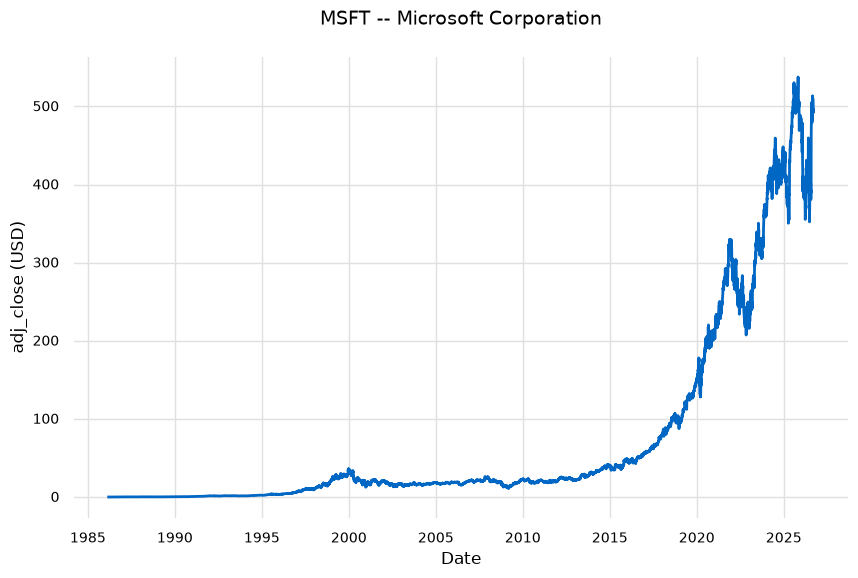

In [11]:
plot_client_series(series, meta=meta)